In [153]:
import rasterio
import numpy as np
from scipy.ndimage import label
def expand_region(array):
	"""
    Shrinks a binary region in a 2D array by removing 
    pixels around the regions.

    Parameters
	----------
    array:numpy array
		2D NumPy array of integers. 

    Returns
	-------
    	2D NumPy array with the shrunk region.

    This function first converts the input array to integers. 
    Then, it identifies and removes single-pixel protrusions 
    from the binary region represented by non-zero values 
    in the array. 
    """
	array = np.array(array, dtype=int)
	array[array < 0] = 0
	array[array > 0] = 1
	
	aux = array.copy()
	array[np.diff(aux, append=0, axis=1) == 1] = 1
	array[np.diff(aux, append=0, axis=0) == 1] = 1
	array[np.diff(aux, prepend=0, axis=0) == -1] = 1
	array[np.diff(aux, prepend=0, axis=1) == -1] = 1
	
	return array

def mask_lakes(array):
	array = np.array(array, dtype=int)
	array[array < 0] = 0
	array[array > 0] = 1
	return array

def get_water_body_parameters(depth, area=None):
    """This function calculates all water body parameters required to run
    the water body component
    
    Parameters
    ----------
    depth :	numpy array
        bathymetry of the water body [m]
    area :	numpy array
        surface area of the water body [m2]
    
    Returns
    -------
    tuple of lists/arrays
        name_lks : array
            labels of lake cells (for returned ids)
        ids_lks : list
            flat indices of all lake cells (flattened, grouped by lake label)
        size_lks : list
            number of cells in each lake
        ids_max_depth_lks : list
            flat indices of the cell with maximum depth in each lake
        depths : array
            depth values corresponding to ids_lks
    """
    # mask lakes from depth
    name_lks = (depth > 0).astype(int)
    #print(name_lks)
    # label lakes (connected components)
    labeled, num_features = label(name_lks)

    # build groups of flat indices per labeled lake (1..num_features)
    flat = labeled.flatten()
    ids_group_by_label = []
    for lab in range(1, num_features + 1):
        ids = list(np.where(flat == lab)[0])
        ids_group_by_label.append(ids)

    # flatten groups to single list of ids (grouped by label)
    ids_lks = [idx for grp in ids_group_by_label for idx in grp]

    # sizes per lake
    size_lks = [len(grp) for grp in ids_group_by_label]

    # find index of maximum depth within each group (global flat index)
    depth_flat = depth.flatten()
    ids_max_depth_lks = []
    for grp in ids_group_by_label:
        if len(grp) == 0:
            continue
        grp_depths = depth_flat[grp]
        imax = int(np.argmax(grp_depths))
        ids_max_depth_lks.append(grp[imax])

    # reduce name array to only the returned ids (labels for those ids)
    name_lks_out = flat[ids_lks]

    # reduce depth array to those ids
    depths_out = depth_flat[ids_lks]

    return name_lks_out, ids_lks, size_lks, ids_max_depth_lks, depths_out

In [1]:
def compute_lake_modified_dem(dem, bathymetry, riv_elevation):
    """
    Generates a modified DEM and river bottom elevation by expanding lakes,
    computing lake surface elevation, and blending with river elevations.
    Lake surface elevation uses the minimum elevation found along the border
    of the lake.

    This function can also be used when the domain contains multiple lakes.

    Parameters
    ----------
    dem : ndarray
        Original DEM raster.
    bathymetry : ndarray
        Water / mask input to detect lakes.
    riv_elevation : ndarray
        River bottom elevation raster.

    Returns
    -------
    dem_lks : ndarray
        Modified DEM including lake surfaces.
    river_bottom_mod : ndarray
        River bottom elevations modified at lake locations.
    """

    # ------------------------
    # 1. Lake mask
    # ------------------------
    mask = mask_lakes(bathymetry)

    # ------------------------
    # 2. Identify lake IDs
    # ------------------------
    lake_labels, lake_ids, *_ = get_water_body_parameters(bathymetry)

    # ------------------------
    # 3. Expand lake region
    # ------------------------
    mask_expand = expand_region(bathymetry)
    expanded_labels, expanded_ids, *_ = get_water_body_parameters(mask_expand)

    # ------------------------
    # 4. Create border elevations (expanded - lake interior)
    # ------------------------
    border = np.where((mask_expand > 0) & (mask == 0), data0, np.nan)

    # Flatten once for efficiency
    border_flat = border.ravel()

    lake_labels = np.asarray(lake_labels)
    expanded_labels = np.asarray(expanded_labels)
    lake_ids = np.asarray(lake_ids)
    expanded_ids = np.asarray(expanded_ids)

    # ------------------------
    # 5. Compute lake surface elevation using min border elevation
    # ------------------------
    surface = np.zeros(mask.size)  # flattened
    unique_lakes = np.unique(expanded_labels)

    for lake in unique_lakes:
        # expanded region pixel indices for this lake
        i_exp = np.where(expanded_labels == lake)[0]

        # find lake perimeter elevation
        min_elev = np.nanmin(border_flat[expanded_ids[i_exp]])

        # interior lake indices
        i_lake = np.where(lake_labels == lake)[0]
        surface[lake_ids[i_lake]] = min_elev

    surface = surface.reshape(mask.shape)

    # ------------------------
    # 6. Construct DEM with lake surface elevations
    # ------------------------
    dem_lks = dem.copy()
    dem_lks[mask > 0] = surface[mask > 0]

    # ------------------------
    # 7. Modify river bottom elevations inside lakes
    # ------------------------
    river_bottom_mod = np.where(mask > 0, dem_lks, riv_elevation)

    # ------------------------
    # 8. Average DEM and river bottom at expanded river locations
    # ------------------------
    avg_river_elevation = 0.5 * (river_bottom_mod + dem_lks)

    data_river_elevation = np.where(
        data_expand > 0, avg_river_elevation, riv_elevation
    )

    return dem_lks, data_river_elevation

In [283]:
path_dem0 = "/home/c1755103/testcuwalid/mk_jibiya/input/mk_dem_filled_f_aligned_clipped.asc"
path_dem = '/home/c1755103/testcuwalid/mk_jibiya/input/dem_with_updated_lakes_meandem_f_aligned_clipped.asc'
path_bathymetry = '/home/c1755103/testcuwalid/mk_jibiya/input/mk_tlab_domain_lakes_nodatatozero_aligned_clipped.asc'
path_riv_len = '/home/c1755103/testcuwalid/mk_jibiya/input/mk_river_network_jibiya_lake_f_aligned_clipped.asc'
path_river_bottom = '/home/c1755103/testcuwalid/mk_jibiya/input/Maradi_Katsina_DEM_3s_utm_30P_resampledto30s_aligned_clipped.asc'

In [284]:
# ----------------------------
# Load rasters
# ----------------------------
with rasterio.open(path_dem0) as r1:
    data0 = r1.read(1)
    transform = r1.transform

with rasterio.open(path_dem) as r1:
    data1 = r1.read(1)
    transform = r1.transform

with rasterio.open(path_bathymetry) as r2:
    data2 = r2.read(1)

with rasterio.open(path_river_bottom) as r3:
    data3 = r3.read(1)

In [285]:
dem_lks, data_river_elevation = compute_lake_modified_dem(data0, data2, data3)

In [168]:
# identify lakes
#depth = data2.copy()
#depth[depth > 0] = 1


In [158]:
#name_lks_out
#ids_lks
#data2.min()
#plt.imshow(data2)
#data2[data2 <= 0] = 0
#data2
#depth

In [266]:
# 1. Create mask of lakes
mask = mask_lakes(data2)

# 2. identify lakes ids
name_lks_out, ids_lks, _, _, _ = get_water_body_parameters(data2)

# 2. Expand lakes one cell
mask_expand = expand_region(data2)

# 2.1 Identify the minimum depth for the lake surface
#border = np.where(mask_expand-mask > 0, data0, border)
ename_lks_out, eids_lks, _, _, _ = get_water_body_parameters(mask_expand)

border = np.zeros_like(mask_expand)
border = np.where(mask_expand-mask > 0, data0, np.nan)

border_flat = border.flatten()
eids_lks = np.array(eids_lks)
ids_lks = np.array(ids_lks)

# 2.2 modify dem with new lake information
surface_lks = np.zeros_like(mask_expand.reshape(-1))
unique_ids = np.unique(ename_lks_out)
for ilake in unique_ids:
    iids_elks = np.where(ename_lks_out == ilake)[0]
    min_elevation = np.nanmin(border_flat[eids_lks[iids_elks]])
    iids_lks = np.where(name_lks_out == ilake)[0]
    surface_lks[ids_lks[list(iids_lks)]] = min_elevation

surface_lks = surface_lks.reshape(mask.shape)

dem_lks = data0.copy()
dem_lks[mask > 0] = surface_lks[mask > 0]

# 3. Make all river elevations at lakes equal to the surface elevation
river_bottom_mod = np.where(mask > 0, dem_lks, data3)
#river_bottom_mod = np.where(mask_expand > 0, dem_lks, data3)

# 4. get average of the two raster datasets
avg_river_elevation = (river_bottom_mod + dem_lks)*0.5

# 5. replace values in the expanded river bottom elevation
data_river_elevation = data3.copy()
data_river_elevation = np.where(data_expand > 0, avg_river_elevation, data3)

In [267]:
#plt.imshow(data_expand, alpha=0.5)
#plt.imshow(mask, alpha=0.5)
#ids_max_depth_lks
#surface_lks
#ids_lks
#iids_elks
#unique_ids
#list(iids_lks)
#name_lks_out
#ename_lks_out
#ids_lks[ids_lks]
#min_elevation
#border_flat[iids_elks]
#border_flat[eids_lks]

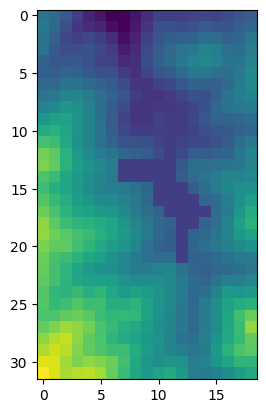

In [286]:
#plt.imshow(data2)
#plt.imshow(border)
#plt.imshow(surface_lks)
#border
plt.imshow(dem_lks)

In [269]:
#plt.imshow(data_river_elevation - data3)

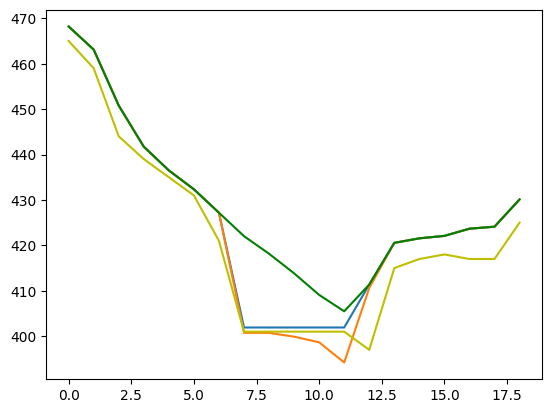

In [287]:
nx = 13
plt.plot(dem_lks[nx])#, 'p')
plt.plot(dem_lks[nx]-data2[nx])#, 'p')
#plt.plot(data1[nx]-data2[nx], 'r.-')
#plt.plot(data_river_elevation[nx])
plt.plot(river_bottom_mod[nx], 'y')
plt.plot(data0[nx], 'g')
#plt.plot(data1[nx], 'k')
#plt.plot(data3[nx], 'b')

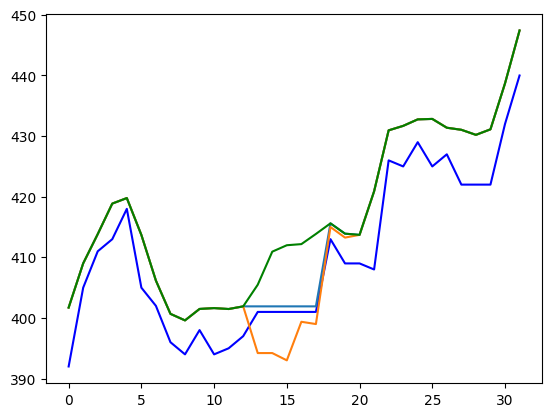

In [288]:
ny = 11
#plt.plot(data1[:, ny]-data2[:, ny], 'r.-')
#plt.plot(data_river_elevation[:, ny])
plt.plot(river_bottom_mod[:, ny], 'b')
plt.plot(dem_lks[:, ny])#, 'p')
plt.plot(dem_lks[:, ny]-data2[:, ny])#, 'p')
plt.plot(data0[:, ny], 'g')
#plt.plot(data1[:, ny], 'k')
#plt.plot(data3[:, ny], 'b')

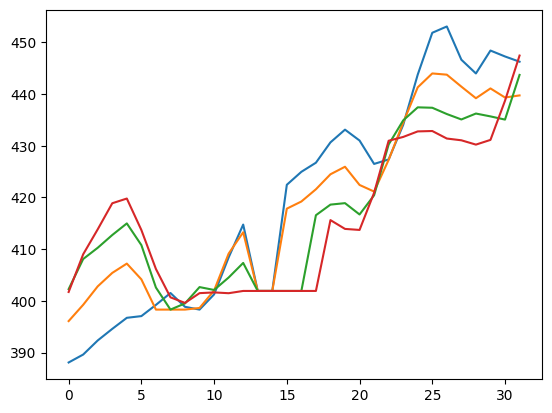

In [289]:
for iny in range(8,12):
	#plt.plot(data1[:, ny]-data2[:, ny], 'r.-')
	#plt.plot(data_river_elevation[:, ny])
	#plt.plot(river_bottom_mod[:, ny], 'y')
	plt.plot(dem_lks[:, iny])#, 'p')
	#plt.plot(data0[:, iny], 'g')
	#plt.plot(data1[:, ny], 'k')
	#plt.plot(data3[:, ny], 'b')

In [56]:
import os
def open_raster(fname):
	"""read raster file
	Parameters
	----------
	fname : str
		file name of the raster
	
	Returns
	-------
	data : numpy array
		raster values
	profile : object
		raster properties
	transform : object
		transformation parameters to pass to other functions
	
	"""
	with rasterio.open(fname) as src:
		# Read the input raster data
		data = src.read(1)
		# Get the metadata of the input raster
		profile = src.profile
		# Get the affine transformation
		transform = src.transform
	return data, profile, transform

def save_raster(fname, data, profile, transform):
	"""This function saves a raster file with the specified name.
	
	Parameters:
	-----------
	fname : str
		file name of the raster
		The raster file will be created with the specified name.
		The raster file will contain the data and properties specified in the profile.
		Make sure to provide the correct file path and name for the raster file.
		Example: "path/to/raster_file.tif"
		Note: The raster file will be created in the same format as the input raster file.
	
	data : numpy array
		raster values
		The data array contains the raster values that you want to save.
		The data array should be a 2D numpy array representing the raster data.
		The data array should have the same dimensions as the raster file.
		For example, if you have a 100x100 raster, the data array should be of shape (100, 100).
		Make sure to provide the correct data array for the raster file.
		Example: np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
		Note: The data array should be in the same format as the input raster file.
		For example, if the input raster file is in GeoTIFF format, the data array should be in GeoTIFF format.
		Make sure to provide the correct data array for the raster file.
		
	profile : object
		raster properties
		The profile object contains the metadata and properties of the raster file.
		It should be obtained from the input raster file using rasterio.
		The profile object should include information such as data type, dimensions, and coordinate reference system.


	transform : object
		transformation parameters
		The transform object contains the affine transformation parameters for the raster file.
		It should be obtained from the input raster file using rasterio.
		The transform object should include information such as pixel size and origin coordinates.


	Returns:
	--------
	None
		None, but creates a raster file with the specified name.
		The raster file will contain the data and properties specified in the profile.
		Note: The function does not return any values, but it saves the raster file with the specified name.

	Example:
	--------

	>>> fname = "output_raster.asc"
	>>> data = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
	>>> profile = {}
	>>> transform = Affine(1, 0, 0, 0, -1, 0)
	>>> save_raster(fname, data, profile, transform)
	>>> # This will create a raster file named "output_raster.asc"
	>>> # with the specified data and properties.
	>>> # The function does not return any values, but it saves the raster file.


	"""
	# Update the profile with the new data type and dimensions
	os.remove(fname) if os.path.exists(fname) else None
	with rasterio.open(fname, 'w', **profile) as dst:
		# Write the modified raster data
		# ensure that data has the same format type
		dst.write(np.array(data, dtype=profile['dtype']), 1)
		# Set the affine transformation
		dst.transform = transform

In [273]:
_, profile, transform = open_raster(path_river_bottom)
fname = '/home/c1755103/testcuwalid/mk_jibiya/input/Maradi_Katsina_DEM_3s_utm_30P_resampledto30s_aligned_clipped_mod.asc'
save_raster(fname, data_river_elevation, profile, transform)

In [274]:
_, profile, transform = open_raster(path_river_bottom)
fname = '/home/c1755103/testcuwalid/mk_jibiya/input/dem_with_updated_lakes_meandem_f_aligned_clipped_mod.asc'
save_raster(fname, dem_lks, profile, transform)

In [277]:
path_ksat_river = "/home/c1755103/testcuwalid/mk_jibiya/input/mk_tlab_domain_ks_utm_mm_perh_v2_aligned_clipped.asc"

In [278]:
# ----------------------------
# Load rasters
# ----------------------------
with rasterio.open(path_ksat_river) as r1:
    data5 = r1.read(1)
    #transform = r1.transform

In [279]:
data5[mask > 0] = 1000.0

In [280]:
_, profile, transform = open_raster(path_river_bottom)
fname = '/home/c1755103/testcuwalid/mk_jibiya/input/mk_tlab_domain_ks_utm_mm_perh_v2_aligned_clipped_mod.asc'
save_raster(fname, data5, profile, transform)